In [2]:
pip install gymnasium minigrid stable-baselines3 gym_minigrid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 11.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 9.6 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827728 sha256=49003ba8d5be669ce1d4c7449dda904bfb4236f76663ba24bdbc43227e05c6cc
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

# MiniGrid Kitchen Environment — RL with PPO

This notebook walks through a complete reinforcement learning pipeline for a **custom MiniGrid kitchen environment**. The agent's task is to clean dirty dishes by:

1. **Picking up** dirty dishes (red balls) from the kitchen grid
2. **Rinsing** them at the sink (top-left corner) using the toggle action
3. **Loading** them into the dishwasher (bottom-right corner) using the toggle action

We use **Proximal Policy Optimization (PPO)** from Stable-Baselines3 with a custom CNN feature extractor to train the agent from pixel observations.

### Outline
1. Imports & Configuration
2. Custom Kitchen Environment Definition
3. Environment Registration
4. CNN Feature Extractor
5. Environment Factory
6. Training
7. Evaluation
8. Video Recording

## 1. Imports & Configuration

We import the following key libraries:

- **`gymnasium`** — the standard RL environment interface (successor to OpenAI Gym)
- **`minigrid`** — a suite of lightweight, grid-based environments perfect for RL research
- **`stable_baselines3`** — high-quality implementations of RL algorithms (PPO, A2C, DQN, etc.)
- **`torch`** — PyTorch, used under the hood by SB3 and for defining our custom CNN
- **`imageio`** — for saving rollout frames as video files

We also set a global seed and environment ID for reproducibility.

In [61]:
import gymnasium as gym
import minigrid
from minigrid.wrappers import ImgObsWrapper

import torch as th
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage

import imageio
from pathlib import Path
import numpy as np
import random
from typing import List, Tuple

CURRENT_DIR = Path(".")  # notebook runs from its own directory
ENV_ID = "MiniGrid-Kitchen-v0"
SEED = 42

### MiniGrid Internal Imports

We need access to MiniGrid's internal building blocks to create our custom environment:

| Class | Purpose |
|---|---|
| `MiniGridEnv` | Base class for all MiniGrid environments |
| `Grid` | The 2D grid that holds all objects |
| `Ball` | Used here to represent dirty dishes (red balls) |
| `Goal` | Used to represent the dishwasher location |
| `Wall` | Obstacles / countertops in the kitchen |

The import path varies between `minigrid` and `gym_minigrid` depending on the installed version, so we try both.

In [62]:
try:
    # Modern minigrid (gymnasium compatible) - for version 3.0+
    from minigrid.core.grid import Grid
    from minigrid.core.world_object import Ball, Goal, Wall
    from minigrid.minigrid_env import MiniGridEnv
except ImportError:
    # Fallback for older versions
    try:
        from minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall
    except ImportError:
        from gym_minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall

## 2. Custom Kitchen Environment

The `KitchenMiniGridEnv` extends MiniGrid's base environment with a custom kitchen scenario.

### Grid Layout
- **5×5 grid** surrounded by walls
- **Sink** at position `(1, 1)` — top-left interior
- **Dishwasher** (Goal tile) at position `(3, 3)` — bottom-right interior
- **1–3 dirty dishes** (red Balls) placed randomly
- **1 random wall** placed as a counter obstacle

### Reward Structure

| Event | Reward |
|---|---|
| Every step | **-0.01** (encourages efficiency) |
| Rinsing a dish at the sink | **+0.2** (intermediate reward for progress) |
| Loading a rinsed dish into dishwasher | **+1.0** (main objective reward) |
| Tight looping (optional) | **-0.5** (anti-loop penalty when enabled) |

### Dish Cleaning Logic
The agent must follow a specific sequence:
1. Navigate to a dish and **pick it up** (pickup action)
2. Navigate to the sink at `(1,1)` and **toggle** → marks the dish as "rinsed"
3. Navigate to the dishwasher at `(width-2, height-2)` and **toggle** → dish is cleaned, reward granted

### Anti-Loop Detection
When `anti_loop_penalty=True`, the environment tracks the agent's last 20 positions. If the last 6 positions only contain ≤ 2 unique locations, a penalty of -0.5 is applied to discourage the agent from getting stuck in repetitive movement patterns.

### Termination
The episode ends when:
- All dishes have been cleaned (no balls remain on the grid or in the agent's inventory), or
- The maximum number of steps (`max_steps=100`) is reached

In [74]:
import gymnasium as gym
import gymnasium.utils.seeding
from typing import Tuple
import numpy as np

# Import MiniGrid components
try:
    # Modern minigrid (gymnasium compatible) - for version 3.0+
    from minigrid.core.grid import Grid
    from minigrid.core.world_object import Ball, Goal, Wall
    from minigrid.minigrid_env import MiniGridEnv
except ImportError:
    # Fallback for older versions
    try:
        from minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall
    except ImportError:
        from gym_minigrid.minigrid import MiniGridEnv, Grid, Ball, Goal, Wall

class KitchenMiniGridEnv(MiniGridEnv):
    """
    MiniGrid environment representing a tiny kitchen:
    - Dirty dishes are represented as red Ball objects.
    - Dishwasher is a Goal tile: dropping a dish on the dishwasher counts as 'cleaned'.
    - NO SINK: Simplified task (Pickup -> Load).
    """

    def __init__(
        self,
        size: int = 8,
        num_dishes: Tuple[int, int] = (1, 3),
        max_steps: int = 200,
        seed: int = None,
        anti_loop_penalty: bool = False,
        render_mode: str = "rgb_array",
    ):
        self.kitchen_size = size
        self.num_dishes_range = num_dishes
        self.anti_loop_penalty = anti_loop_penalty

        # Define the mission space (required by newer minigrid versions)
        mission_space = gym.spaces.Text(max_length=256)

        super().__init__(
            mission_space=mission_space,
            width=size, height=size, max_steps=max_steps, see_through_walls=True,
            render_mode=render_mode
        )
        self.seed(seed)
        self.cleaned_count = 0
        self.total_dishes = 0
        self.dish_ids = []
        self._last_positions = []

    def seed(self, seed=None):
        """Explicitly define seed method for compatibility."""
        self.np_random, seed = gymnasium.utils.seeding.np_random(seed)
        return [seed]

    def _gen_grid(self, width, height):
        """Generate the kitchen grid layout."""
        # Create an empty grid with walls around the border
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # Place dishwasher (Goal) at bottom-right interior
        dx = width - 2
        dy = height - 2
        self.put_obj(Goal(), dx, dy)
        self.dishwasher_pos = (dx, dy)

        # --- SIMPLIFIED: NO SINK ---

        # Place 1-3 dirty dishes (red Ball objects) at random free cells
        num_dishes = self._rand_int(self.num_dishes_range[0], self.num_dishes_range[1] + 1)
        self.total_dishes = num_dishes # Track total for termination
        self.dish_ids = []
        placed = 0
        while placed < num_dishes:
            x = self._rand_int(1, width - 1)
            y = self._rand_int(1, height - 1)
            if self.grid.get(x, y) is None and (x, y) != self.dishwasher_pos:
                ball = Ball(color="red")
                ball.already_picked = False  # Track for one-time reward
                self.put_obj(ball, x, y)
                self.dish_ids.append(ball.cur_pos)
                placed += 1

        # Place the agent at a random free cell
        self.place_agent()
        self.mission = "Clean the dishes: pick up and load into dishwasher."

    def step(self, action):
        """
        Extend step with custom reward shaping for the dish-cleaning task.
        """
        # --- TYPE SAFETY: Ensure action is a standard integer ---
        if hasattr(action, "item"):
            action = action.item()
        action = int(action)

        pre_carrying = self.carrying

        # --- 1. RESTRICT PICKUP (Facing Only) ---
        if action == self.actions.pickup:
            fwd_cell = self.grid.get(*self.front_pos)
            # If there is nothing in front, or it's not a ball, BLOCK the action.
            if fwd_cell is None or fwd_cell.type != 'ball':
                # print("[Env] Blocked Pickup: Nothing in front!") # Debug
                action = self.actions.done

        # --- 2. DISABLE DROP (No Dropping Anywhere) ---
        if action == self.actions.drop:
            # print("[Env] Blocked Drop: Action Disabled!") # Debug
            action = self.actions.done

        # --- 3. LOADING (Toggle Only) ---
        custom_load = False

        # Check location: Is agent facing the dishwasher OR standing on it?
        target_is_dishwasher = (tuple(self.front_pos) == self.dishwasher_pos) or (tuple(self.agent_pos) == self.dishwasher_pos)

        # Check action: TOGGLE only
        is_load_action = (action == self.actions.toggle)

        if is_load_action and target_is_dishwasher:
            if self.carrying and self.carrying.type == 'ball':
                # SUCCESS: Dish loaded!
                custom_load = True
                self.carrying = None

        # Run standard step
        obs, reward, terminated, truncated, info = super().step(action)

        # Apply Loading Rewards
        if custom_load:
            reward += 2.5
            self.cleaned_count += 1

        # --- FIX: Prevent premature termination at dishwasher ---
        if terminated and tuple(self.agent_pos) == self.dishwasher_pos:
             reward = 0
             terminated = False

        # Step penalty to encourage efficiency
        reward = reward - 0.01

        # --- One-time Pickup Reward ---
        if pre_carrying is None and self.carrying is not None:
             if not getattr(self.carrying, 'already_picked', False):
                  reward += 0.5
                  self.carrying.already_picked = True

        # --- TERMINATION ---
        if self.cleaned_count >= self.total_dishes:
            terminated = True
            reward += 1.0 # Bonus for finishing

        # --- DEBUG INFO ---
        if terminated or truncated:
            info["dishes_cleaned"] = self.cleaned_count

        return obs, reward, terminated, truncated, info

## 3. Environment Registration

We register the custom environment with Gymnasium's registry so it can be instantiated via `gym.make("MiniGrid-Kitchen-v0", ...)`. This is the standard pattern for creating reusable custom environments.

The `try/except` block handles the case where the environment is already registered (e.g., if this cell is re-run).

In [75]:
from gymnasium.envs.registration import register, registry

# Force re-registration to ensure max_episode_steps is updated
if ENV_ID in registry:
    del registry[ENV_ID]

register(
    id=ENV_ID,
    entry_point=lambda **kwargs: KitchenMiniGridEnv(**kwargs),
    max_episode_steps=200, # Increased to 200
)

## 4. CNN Feature Extractor

Since our observations are **pixel images** of the grid (thanks to `ImgObsWrapper`), we need a convolutional neural network to extract meaningful features before feeding them into the PPO policy and value networks.

### Architecture

```
Input Image (C, H, W)
    │
    ├── Conv2d(C → 32, 3×3, padding=1) + ReLU
    ├── Conv2d(32 → 64, 3×3, padding=1) + ReLU
    ├── Conv2d(64 → 64, 3×3, padding=1) + ReLU
    ├── Flatten
    └── Linear(flattened → 128) + ReLU
         │
         └── 128-dim feature vector
```

Key design choices:
- **3×3 kernels with padding=1** preserve spatial dimensions, which is important for small grid images
- **No pooling layers** — the MiniGrid observations are already very small (e.g., 7×7×3), so we don't want to downsample further
- The flattened CNN output is projected to a **128-dimensional** feature vector that PPO's policy and value heads consume

In [65]:
class MinigridFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        n_input_channels = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        # Dynamically compute the flattened size by passing a dummy input
        with th.no_grad():
            sample = observation_space.sample()[None]
            sample = th.as_tensor(sample).float()
            n_flatten = self.cnn(sample).shape[1]
        self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.ReLU())

    def forward(self, observations):
        return self.linear(self.cnn(observations))


policy_kwargs = dict(
    features_extractor_class=MinigridFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=128),
)

## 5. Environment Factory

The `make_env` function is a **factory** that returns a callable which creates a properly wrapped environment. This pattern is required by SB3's vectorized environment wrappers.

The wrapping chain is:
1. `gym.make(...)` → creates the raw `KitchenMiniGridEnv`
2. `ImgObsWrapper(env)` → extracts only the image observation (discarding the mission string and direction), returning `(H, W, C)` arrays
3. `DummyVecEnv([make_env()])` → wraps it in SB3's vectorized env interface (batch dimension)
4. `VecTransposeImage(vec_env)` → transposes images from `(H, W, C)` to `(C, H, W)` as PyTorch expects

In [79]:
from stable_baselines3.common.monitor import Monitor
from minigrid.wrappers import FullyObsWrapper

def make_env(seed=SEED, size=8, anti_loop_penalty=False):
    """Returns a callable that creates a wrapped MiniGrid kitchen environment."""
    def _init():
        env = gym.make(
            ENV_ID,
            size=size,
            num_dishes=(1, 3),
            max_steps=200,
            seed=seed,
            anti_loop_penalty=anti_loop_penalty,
            render_mode="rgb_array"
        )

        # --- CRITICAL FIX: Restore God View ---
        # The model was trained with this wrapper. It MUST be present for evaluation.
        env = FullyObsWrapper(env)

        # Wrap with Monitor to track episode stats (reward, length)
        env = Monitor(env)
        env = ImgObsWrapper(env)
        return env

    return _init

## 6. Training

We train a **PPO (Proximal Policy Optimization)** agent — one of the most popular and reliable on-policy RL algorithms.

### PPO Hyperparameters

| Parameter | Value | Description |
|---|---|---|
| `learning_rate` | 3e-4 | Adam optimizer learning rate |
| `n_steps` | 1024 | Number of steps per rollout before each update |
| `batch_size` | 64 | Minibatch size for each gradient step |
| `n_epochs` | 10 | Number of passes over the rollout buffer per update |
| `gamma` | 0.99 | Discount factor — how much the agent values future rewards |
| `gae_lambda` | 0.95 | GAE (Generalized Advantage Estimation) smoothing factor |
| `clip_range` | 0.2 | PPO clipping range — limits how much the policy can change per update |
| `ent_coef` | 0.02 | Entropy bonus — encourages exploration |
| `vf_coef` | 0.5 | Value function loss coefficient |
| `max_grad_norm` | 0.5 | Gradient clipping to prevent exploding gradients |

### Training Pipeline
1. Set random seeds for reproducibility
2. Create a vectorized environment with image transposition
3. Instantiate PPO with the custom CNN feature extractor
4. Train for 200,000 timesteps (adjustable)
5. Save the trained model to disk

In [68]:
from stable_baselines3.common.callbacks import BaseCallback
import rich

# --- FIX: Force clear stuck 'Live' displays from interrupted runs ---
try:
    # Get the global console used by rich and force-close any active Live display
    console = rich.get_console()
    if hasattr(console, '_live') and console._live is not None:
        console._live.stop()
        console._live = None
except Exception as e:
    print(f"Cleanup ignored: {e}")

class DebugCallback(BaseCallback):
    """
    Custom callback for plotting additional values in tensorboard.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.dishes_cleaned = []
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # Check for episode end in the vectorized environment
        for info in self.locals['infos']:
            if "dishes_cleaned" in info:
                self.dishes_cleaned.append(info["dishes_cleaned"])
                self.logger.record("custom/dishes_cleaned", info["dishes_cleaned"])
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])

        return True

    def _on_rollout_end(self) -> None:
        # Print stats at the end of each rollout (every n_steps)
        if self.dishes_cleaned:
            avg_cleaned = np.mean(self.dishes_cleaned)
            avg_rew = np.mean(self.episode_rewards) if self.episode_rewards else 0.0
            print(f"[Debug] Rollout End - Avg Dishes Cleaned: {avg_cleaned:.2f} | Avg Reward: {avg_rew:.2f}")
            # Log to Tensorboard
            self.logger.record("rollout/avg_dishes_cleaned", avg_cleaned)

        self.dishes_cleaned = []
        self.episode_rewards = []

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
th.manual_seed(SEED)

# Create vectorized environment
# TRAIN ON 8x8 GRID with FullyObsWrapper
vec_env = DummyVecEnv([make_env(seed=SEED, size=8, anti_loop_penalty=True)])
vec_env = VecTransposeImage(vec_env)

# Initialize PPO with custom CNN policy
model = PPO(
    "CnnPolicy",
    vec_env,
    policy_kwargs=policy_kwargs,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.05,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    verbose=1,
    tensorboard_log=str(CURRENT_DIR / "logs"),
)

# Train the agent
print("Starting training on 8x8 grid (Simplified Task: Pickup->Load, Fully Observable) for 200k steps...")
# Re-enabled progress_bar with the fix above
model.learn(total_timesteps=200_000, progress_bar=True, callback=DebugCallback())

# Save the trained model
model_path = CURRENT_DIR / "model"
model.save(model_path)
print(f"Model saved to {model_path}.zip")

Using cuda device
Starting training on 8x8 grid (Simplified Task: Pickup->Load, Fully Observable) for 200k steps...
Logging to logs/PPO_12


Output()

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs 
returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[Debug] Rollout End - Avg Dishes Cleaned: 0.00 | Avg Reward: -1.90

...

[Debug] Rollout End - Avg Dishes Cleaned: 3.00 | Avg Reward: 1.01

-----------------------------------------
| custom/                 |             |
|    dishes_cleaned       | 3           |
| rollout/                |             |
|    avg_dishes_cleaned   | 3           |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | 1.02        |
| time/                   |             |
|    fps                  | 256         |
|    iterations           | 195         |
|    time_elapsed         | 779         |
|    total_timesteps      | 199680      |
| train/                  |             |
|    approx_kl            | 0.049031425 |
|    clip_fraction        | 0.36        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.78       |
|    explained_variance   | 0.767       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.106      |
|    n_updates            | 1940        |
|    policy_gradient_loss | -0.0529     |
|    value_loss           | 0.00143     |
----------------------------------

[Debug] Rollout End - Avg Dishes Cleaned: 3.00 | Avg Reward: 1.01

-----------------------------------------
| custom/                 |             |
|    dishes_cleaned       | 3           |
| rollout/                |             |
|    avg_dishes_cleaned   | 3           |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | 1           |
| time/                   |             |
|    fps                  | 256         |
|    iterations           | 196         |
|    time_elapsed         | 783         |
|    total_timesteps      | 200704      |
| train/                  |             |
|    approx_kl            | 0.040591918 |
|    clip_fraction        | 0.291       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.77       |
|    explained_variance   | 0.633       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.139      |
|    n_updates            | 1950        |
|    policy_gradient_loss | -0.0422     |
|    value_loss           | 0.00287     |
----------------------------------

Model saved to model.zip


## 7. Evaluation

After training, we evaluate the agent's performance over multiple episodes using SB3's `evaluate_policy` utility. This runs the trained policy in the environment for `n_eval_episodes` episodes and computes the **mean** and **standard deviation** of the total episode rewards.

A higher mean reward indicates that the agent has learned to:
- Efficiently pick up dishes
- Rinse them at the sink
- Load them into the dishwasher
- Minimize wasted steps

We use a different seed (`SEED + 1`) for evaluation to test generalization to unseen random configurations.

In [76]:
# Use DummyVecEnv and VecTransposeImage to match training preprocessing
eval_env = DummyVecEnv([make_env(seed=SEED + 1, size=8, anti_loop_penalty=True)])
eval_env = VecTransposeImage(eval_env)

mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=20)
print(f"\nEvaluation results (20 episodes): Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")

eval_env.close()

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



Evaluation results (20 episodes): Mean reward: -2.00 ± 0.00


## 8. Video Recording

Finally, we record a video of the trained agent performing a single episode. This is useful for:
- **Visual debugging** — seeing if the agent actually follows the rinse → load sequence
- **Presentations** — demonstrating the learned behavior
- **Sanity checks** — verifying the environment renders correctly

The video is saved as `demo.mp4` at 6 FPS. Each frame is captured using `env.render(mode="rgb_array")`.

In [82]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
import os

# Create a vectorized environment exactly like training
# We use the SAME SEED (42) to verify it works on the configuration it learned
video_env = DummyVecEnv([make_env(seed=SEED, size=8, anti_loop_penalty=True)])
video_env = VecTransposeImage(video_env)

frames: List[np.ndarray] = []
obs = video_env.reset()

# Access the underlying raw environment for rendering and info
raw_env = video_env.envs[0]

def annotate_frame(env, frame, step_idx, action_name=None, reward=0.0):
    """Overlay text on the frame to explain what's happening."""
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)

    # Status info
    carried = getattr(env.unwrapped, "carrying", None)
    status = "Idling"
    if carried:
        status = f"Carrying {carried.color} dish"
        if getattr(carried, "rinsed", False):
            status += " (Rinsed)"

    cleaned = getattr(env.unwrapped, "cleaned_count", 0)

    text = f"Step: {step_idx}\nStatus: {status}\nCleaned: {cleaned}"
    if action_name:
        text += f"\nAction: {action_name}"

    draw.text((5, 5), text, fill=(255, 255, 255))
    return np.array(img)

# Initial frame
frame = raw_env.render()
frames.append(annotate_frame(raw_env, frame, 0))

done = False
steps = 0
max_steps = 200
total_reward = 0

print("Recording Episode...")
while not done and steps < max_steps:
    # Use deterministic=False to help agent break out of loops (matches training behavior)
    action, _ = model.predict(obs, deterministic=False)

    obs, reward, dones, infos = video_env.step(action)
    total_reward += reward[0]

    # Check if episode ended
    done = dones[0]

    # Get action name for annotation
    action_idx = action[0]
    action_name = raw_env.unwrapped.actions(action_idx).name

    # Debug print every 20 steps or if interesting action
    if steps % 20 == 0 or action_idx in [3, 5]: # Pickup or Toggle
        print(f"Step {steps}: Action={action_name}, Reward={reward[0]:.2f}, Done={done}")

    frame = raw_env.render()
    annotated_frame = annotate_frame(raw_env, frame, steps + 1, action_name, reward[0])
    frames.append(annotated_frame)

    steps += 1
    if done:
        print(f"Episode finished in {steps} steps. Total Reward: {total_reward:.2f}")
        break

output_path = CURRENT_DIR / "demo.mp4"
imageio.mimsave(output_path, frames, fps=6)
print(f"Video saved to {output_path} ({len(frames)} frames, {steps} steps)")

video_env.close()

# --- Display Video ---
if os.path.exists(output_path):
    mp4 = open(output_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url))
else:
    print(f"Could not find video at {output_path}")

Recording Episode...
Step 0: Action=right, Reward=-0.01, Done=False
Step 7: Action=pickup, Reward=-0.01, Done=False
Step 9: Action=toggle, Reward=-0.01, Done=False
Step 11: Action=pickup, Reward=-0.01, Done=False
Step 12: Action=pickup, Reward=-0.01, Done=False
Step 17: Action=pickup, Reward=-0.01, Done=False
Step 18: Action=pickup, Reward=-0.01, Done=False
Step 20: Action=right, Reward=-0.01, Done=False
Step 21: Action=toggle, Reward=-0.01, Done=False
Step 22: Action=pickup, Reward=-0.01, Done=False
Step 28: Action=toggle, Reward=-0.01, Done=False
Step 33: Action=toggle, Reward=-0.01, Done=False
Step 37: Action=pickup, Reward=-0.01, Done=False
Step 38: Action=toggle, Reward=-0.01, Done=False
Step 40: Action=right, Reward=-0.01, Done=False
Step 48: Action=toggle, Reward=-0.01, Done=False
Step 50: Action=toggle, Reward=-0.01, Done=False
Step 51: Action=toggle, Reward=-0.01, Done=False
Step 56: Action=pickup, Reward=-0.01, Done=False
Step 58: Action=toggle, Reward=-0.01, Done=False
Step 

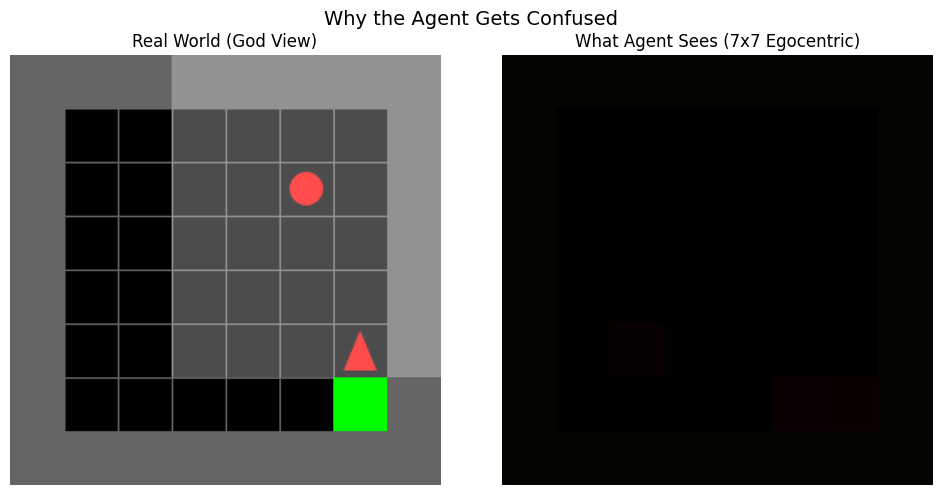

In [48]:
import matplotlib.pyplot as plt

# Get the last observation from the video environment
# obs is currently in (C, H, W) format from the wrapper
obs_agent = obs[0]  # Shape (3, 7, 7)

# Transpose back to (H, W, C) for visualization
obs_agent_viz = np.transpose(obs_agent, (1, 2, 0))

# Create a side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 1. Real World (Global View)
axes[0].imshow(raw_env.render())
axes[0].set_title("Real World (God View)")
axes[0].axis("off")

# 2. Agent's Brain (Egocentric View)
axes[1].imshow(obs_agent_viz)
axes[1].set_title("What Agent Sees (7x7 Egocentric)")
axes[1].axis("off")

plt.suptitle("Why the Agent Gets Confused", fontsize=14)
plt.tight_layout()
plt.show()

---

### Next Steps

- **Enable anti-loop penalty**: Set `anti_loop_penalty=True` in `make_env()` to discourage repetitive agent behavior
- **Increase training timesteps**: Try 500k or 1M steps for better convergence
- **Tune hyperparameters**: Experiment with `ent_coef`, `learning_rate`, or `n_steps`
- **Scale the kitchen**: Increase `size` and `num_dishes` for a harder task
- **Monitor with TensorBoard**: Run `tensorboard --logdir logs/` to visualize training curves